**Overall Purpose**

The code fine-tunes a pre-trained Geneformer model to classify pancreatic cell types from single-cell RNA-seq data that has been tokenized into gene sequences.

Key Sections:

**1. Setup & Environment**

Installs dependencies (scanpy, datasets, etc.)

Clones Geneformer repository

Sets up CUDA memory configuration

Mounts Google Drive for data access

**2. Data Loading & Exploration**

Loads tokenized pancreatic dataset

```
pancreas_dataset = "/content/drive/MyDrive/geneformer_test2/pancreas_scib.dataset"
token_dataset = load_from_disk(pancreas_dataset)
```

Data contains input_ids (tokenized genes), celltype, and other metadata

Explores cell type distribution with visualizations

**3. Data Preprocessing Pipeline**

Filter rare cell types (>10% threshold)

```
clusters_to_keep = [k for k, v in celltype_counter.items() if v > min_cells]

# Keep only full-length sequences (2048 tokens)
filtered_data = filtered_data.filter(lambda x: x["length"] == 2048, num_proc=16)

# Downsample to 1000 cells to avoid memory issues
target_total = 1000
```

**4. Memory Management**

Aggressive downsampling (1000 cells) to prevent CUDA OOM

Uses proportional sampling to maintain cell type ratios

Implements gradient checkpointing and other memory optimizations

**5. Label Preparation**

Create numerical labels for training

target_names = sorted(list(set(train_data["label"])))

celltype_label_dict = {name: idx for idx, name in enumerate(target_names)}

**6. Model Training**

Load pre-trained Geneformer

```
model = BertForSequenceClassification.from_pretrained(
    MODEL,
    num_labels=len(celltype_label_dict.keys()),
    output_attentions=False,
    output_hidden_states=False
).to("cuda")

```

**7. Training Configuration**

Uses conservative settings to avoid memory issues

Implements gradient accumulation and checkpointing

Includes comprehensive evaluation metrics

**Key Features:**

*Memory Optimization:*

Dataset downsampling (1000 cells)

Gradient checkpointing enabled

Batch size = 5 with gradient accumulation

Sequence length capped at 2048

*Data Quality:*

Filters rare cell types (>10% threshold)

Only uses full-length sequences

Maintains proportional cell type distribution

*Biological Relevance:*

Focuses on pancreatic islet cells (beta, alpha, delta, etc.)

Includes cell type distribution analysis

Provides biological context for each cell type

**Overall Purpose**

The code fine-tunes a pre-trained Geneformer model to classify pancreatic cell types from single-cell RNA-seq data that has been tokenized into gene sequences.

Key Sections:

**1. Setup & Environment**

Installs dependencies (scanpy, datasets, etc.)

Clones Geneformer repository

Sets up CUDA memory configuration

Mounts Google Drive for data access

**2. Data Loading & Exploration**

Loads tokenized pancreatic dataset

```
pancreas_dataset = "/content/drive/MyDrive/geneformer_test2/pancreas_scib.dataset"
token_dataset = load_from_disk(pancreas_dataset)
```

Data contains input_ids (tokenized genes), celltype, and other metadata

Explores cell type distribution with visualizations

**3. Data Preprocessing Pipeline**

Filter rare cell types (>10% threshold)

```
clusters_to_keep = [k for k, v in celltype_counter.items() if v > min_cells]

# Keep only full-length sequences (2048 tokens)
filtered_data = filtered_data.filter(lambda x: x["length"] == 2048, num_proc=16)

# Downsample to 1000 cells to avoid memory issues
target_total = 1000
```

**4. Memory Management**

Aggressive downsampling (1000 cells) to prevent CUDA OOM

Uses proportional sampling to maintain cell type ratios

Implements gradient checkpointing and other memory optimizations

**5. Label Preparation**

Create numerical labels for training

target_names = sorted(list(set(train_data["label"])))

celltype_label_dict = {name: idx for idx, name in enumerate(target_names)}

**6. Model Training**

Load pre-trained Geneformer

```
model = BertForSequenceClassification.from_pretrained(
    MODEL,
    num_labels=len(celltype_label_dict.keys()),
    output_attentions=False,
    output_hidden_states=False
).to("cuda")

```

**7. Training Configuration**

Uses conservative settings to avoid memory issues

Implements gradient accumulation and checkpointing

Includes comprehensive evaluation metrics

**Key Features:**

*Memory Optimization:*

Dataset downsampling (1000 cells)

Gradient checkpointing enabled

Batch size = 5 with gradient accumulation

Sequence length capped at 2048

*Data Quality:*

Filters rare cell types (>10% threshold)

Only uses full-length sequences

Maintains proportional cell type distribution

*Biological Relevance:*

Focuses on pancreatic islet cells (beta, alpha, delta, etc.)

Includes cell type distribution analysis

Provides biological context for each cell type

**Overall Purpose**

The code fine-tunes a pre-trained Geneformer model to classify pancreatic cell types from single-cell RNA-seq data that has been tokenized into gene sequences.

Key Sections:

**1. Setup & Environment**

Installs dependencies (scanpy, datasets, etc.)

Clones Geneformer repository

Sets up CUDA memory configuration

Mounts Google Drive for data access

**2. Data Loading & Exploration**

Loads tokenized pancreatic dataset

```
pancreas_dataset = "/content/drive/MyDrive/geneformer_test2/pancreas_scib.dataset"
token_dataset = load_from_disk(pancreas_dataset)
```

Data contains input_ids (tokenized genes), celltype, and other metadata

Explores cell type distribution with visualizations

**3. Data Preprocessing Pipeline**

Filter rare cell types (>10% threshold)

```
clusters_to_keep = [k for k, v in celltype_counter.items() if v > min_cells]

# Keep only full-length sequences (2048 tokens)
filtered_data = filtered_data.filter(lambda x: x["length"] == 2048, num_proc=16)

# Downsample to 1000 cells to avoid memory issues
target_total = 1000
```

**4. Memory Management**

Aggressive downsampling (1000 cells) to prevent CUDA OOM

Uses proportional sampling to maintain cell type ratios

Implements gradient checkpointing and other memory optimizations

**5. Label Preparation**

Create numerical labels for training

target_names = sorted(list(set(train_data["label"])))

celltype_label_dict = {name: idx for idx, name in enumerate(target_names)}

**6. Model Training**

Load pre-trained Geneformer

```
model = BertForSequenceClassification.from_pretrained(
    MODEL,
    num_labels=len(celltype_label_dict.keys()),
    output_attentions=False,
    output_hidden_states=False
).to("cuda")

```

**7. Training Configuration**

Uses conservative settings to avoid memory issues

Implements gradient accumulation and checkpointing

Includes comprehensive evaluation metrics

**Key Features:**

*Memory Optimization:*

Dataset downsampling (1000 cells)

Gradient checkpointing enabled

Batch size = 5 with gradient accumulation

Sequence length capped at 2048

*Data Quality:*

Filters rare cell types (>10% threshold)

Only uses full-length sequences

Maintains proportional cell type distribution

*Biological Relevance:*

Focuses on pancreatic islet cells (beta, alpha, delta, etc.)

Includes cell type distribution analysis

Provides biological context for each cell type

In [1]:
import os
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

In [2]:
!pip install scanpy
!pip install loompy
!pip install datasets

In [3]:
!git lfs install
!git clone https://huggingface.co/ctheodoris/Geneformer
!ls -1

Git LFS initialized.
fatal: destination path 'Geneformer' already exists and is not an empty directory.
drive
Geneformer
models
pancreas_scib.classification_output
pancreas_scib.dataset
sample_data


In [4]:
%cd Geneformer
!pip install -e .

/content/Geneformer
Obtaining file:///content/Geneformer
  Preparing metadata (setup.py) ... done
  Attempting uninstall: geneformer
    Found existing installation: geneformer 0.1.0
    Uninstalling geneformer-0.1.0:
      Successfully uninstalled geneformer-0.1.0
  Running setup.py develop for geneformer


In [5]:
# Mount Google Drive

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


**Load and check the input .dataset after tokenization**

In [33]:
# Copy from Google Drive

import loompy
import scanpy
import datasets
from datasets import load_from_disk

pancreas_dataset = "/content/drive/My Drive/geneformer_test2/pancreas_scib_V1model.dataset"
token_dataset = load_from_disk(pancreas_dataset)

# Print basic info
print("Type of loaded dataset:", type(token_dataset))
print("Dataset summary:")
print(token_dataset)

# Print the feature schema (columns and types)
print("Dataset features:")
print(token_dataset.features)

# Preview the first 2 records
print("\nFirst 2 records:")
print(token_dataset[:2])

# Convert to pandas DataFrame and display the first few rows
df = token_dataset.to_pandas()
print("\nHead of the dataset as pandas DataFrame:")
print(df.head())

# input_ids
# A list of integers, where each integer represents a tokenized gene (mapped from an Ensembl ID) using Geneformer's tokenizer.
# These are the input tokens for the transformer model (similar to word tokens in NLP).

original_dataset = token_dataset

Type of loaded dataset: <class 'datasets.arrow_dataset.Dataset'>
Dataset summary:
Dataset({
    features: ['input_ids', 'batch', 'celltype', 'n_counts', 'obs_names', 'size_factors', 'tech', 'length'],
    num_rows: 16382
})
Dataset features:
{'input_ids': Sequence(feature=Value(dtype='int16', id=None), length=-1, id=None), 'batch': Value(dtype='string', id=None), 'celltype': Value(dtype='string', id=None), 'n_counts': Value(dtype='int64', id=None), 'obs_names': Value(dtype='string', id=None), 'size_factors': Value(dtype='float64', id=None), 'tech': Value(dtype='string', id=None), 'length': Value(dtype='int64', id=None)}

First 2 records:
{'input_ids': [[25307, 20826, 3331, 15251, 2191, 14904, 4773, 14814, 5907, 12768, 2533, 21115, 8337, 4901, 9095, 14525, 3154, 16516, 14026, 5349, 11875, 14694, 3665, 20463, 3699, 2019, 17759, 13339, 12823, 15164, 1930, 18610, 538, 4556, 2729, 15568, 6393, 970, 12565, 3245, 10960, 6288, 14846, 4349, 12764, 1845, 13390, 4119, 2660, 444, 13521, 6297, 2101

**input_ids** - tokenized expression (int IDs representing Ensembl genes)

**cell metadata** - celltype, tech, n_counts, obs_names, batch, etc.

In a Geneformer .dataset object (loaded with load_from_disk()), you cannot directly see gene names — only the input_ids, which are integers (tokens) that represent genes.

These token IDs were created during tokenization by mapping Ensembl gene IDs to integers using a token dictionary. The gene names themselves are not stored inside the .dataset — but - you can recover gene names in the following way :

```
import pickle

with open("/content/Geneformer/geneformer/gene_dictionaries_30m/token_dictionary_gc30M.pkl", "rb") as f:
    token_dict = pickle.load(f)

# Reverse it: token ID → gene (usually Ensembl ID)
token_to_gene = {v: k for k, v in token_dict.items()}

```

In [34]:
# Save the dataset to the new folder
token_dataset.save_to_disk("/content/pancreas_scib.dataset")
print(f"Dataset successfully saved to /content/pancreas_scib.dataset")

Dataset successfully saved to /content/pancreas_scib.dataset


In [35]:
print(df["input_ids"].head())


0    [25307, 20826, 3331, 15251, 2191, 14904, 4773,...
1    [25307, 20335, 23864, 17642, 14613, 20765, 205...
2    [25307, 18549, 20336, 21115, 12620, 18596, 185...
3    [25307, 20335, 23864, 16140, 8262, 15251, 9800...
4    [25307, 23864, 16127, 16918, 8887, 13348, 3598...
Name: input_ids, dtype: object


In [36]:
!ls -1 /content/pancreas_scib.dataset

data-00000-of-00001.arrow
dataset_info.json
state.json


In [37]:
import os
import subprocess
os.environ["NCCL_DEBUG"] = "INFO"
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = ""

In [38]:
def find_gpus(nums=1):
    if nums == 1:
        return ['0']

    os.system('nvidia-smi -q -d Memory | grep Free >tmp_free_gpus')
    with open('tmp_free_gpus', 'r') as lines_txt:
        frees = lines_txt.readlines()
        idx_freeMemory_pair = [ (idx,int(x.split()[2]))
                              for idx,x in enumerate(frees) ]

    idx_freeMemory_pair_correct = []
    step = int(len(idx_freeMemory_pair) / nums)
    for i in range(0, len(idx_freeMemory_pair), step):
        obj = idx_freeMemory_pair[i]
        obj = (int(obj[0]/step), obj[1])
        idx_freeMemory_pair_correct.append(obj)

    idx_freeMemory_pair_correct.sort(key=lambda my_tuple:my_tuple[1],reverse=True)
    usingGPUs = [str(idx_memory_pair[0])
                    for idx_memory_pair in idx_freeMemory_pair_correct[:nums] ]

    print('using GPU idx: #', usingGPUs)
    return usingGPUs

n_gpus = str(subprocess.check_output(["nvidia-smi", "-L"])).count('UUID')
os.environ['CUDA_VISIBLE_DEVICES'] = ','.join(find_gpus(nums=n_gpus)[0])

In [39]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

import datetime
import glob
import pickle
import subprocess

import numpy as np
import pandas as pd
import seaborn as sns

from collections import Counter, defaultdict

from datasets import Dataset, DatasetDict, load_from_disk

from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import train_test_split

from transformers import BertForSequenceClassification, Trainer
from transformers.training_args import TrainingArguments

from geneformer import Classifier, DataCollatorForCellClassification, EmbExtractor

***Set up environment variables***

In [40]:
import sys, os
LIB_PATH=sys.path[1].split("/lib/")[0]
LFS_HOME=f"{LIB_PATH}/bin/git-lfs"
print(LFS_HOME)
# os.system(f"{LFS_HOME} install")
# os.system(f"{LFS_HOME} clone https://huggingface.co/ctheodoris/Geneformer")
# os.system(f"cd ./Geneformer && {LFS_HOME} pull")

/env/python/bin/git-lfs


In [41]:
!pwd
!ls -1 ../

!echo -e "\nThe files in the folder : pancreas_scib.dataset\n"
!ls -1 /content/pancreas_scib.dataset

/content/Geneformer
drive
Geneformer
models
pancreas_scib.classification_output
pancreas_scib.dataset
sample_data

The files in the folder : pancreas_scib.dataset

data-00000-of-00001.arrow
dataset_info.json
state.json


In [42]:
# Pre-train model directory

# pre_model_dir = glob.glob(os.path.join(repo_dir,"*-12L-30M*"))[0]   ### use 12-layer Geneformer model
# pre_model_dir = glob.glob(os.path.join(repo_dir, "*-6L-30M*"))[0]  ### use 6-layer Geneformer model

# Input data set path
# input_prefix = "pancreas_scib"

# pancreas_dataset = token_dataset
original_dataset = token_dataset

# Specific paths

token_dictionary = "/content/Geneformer/geneformer/gene_dictionaries_30m/token_dictionary_gc30M.pkl"
model_v1 = "/content/Geneformer/Geneformer-V1-10M/"
model_v2 = "/content/Geneformer/Geneformer-V2-104M"

input_dir = "/content/content/pancreas_scib.dataset"
output_dir = "/content/pancreas_scib.classification_output"
input_prefix = "pancreas_scib"

In [43]:
print("Loading pancreas dataset...")

# Load the main pancreas dataset
original_dataset = load_from_disk(f"/content/pancreas_scib.dataset/")

print(f"Total cells loaded: {len(original_dataset)}")
print(f"Dataset features: {original_dataset.features}")

# Check if celltype column exists
if "celltype" in original_dataset.features:
    print("✅ 'celltype' is present in the dataset.")
else:
    print("❌ 'celltype' is NOT present in the dataset.")
    print("Available columns:", list(original_dataset.features.keys()))

Loading pancreas dataset...
Total cells loaded: 16382
Dataset features: {'input_ids': Sequence(feature=Value(dtype='int16', id=None), length=-1, id=None), 'batch': Value(dtype='string', id=None), 'celltype': Value(dtype='string', id=None), 'n_counts': Value(dtype='int64', id=None), 'obs_names': Value(dtype='string', id=None), 'size_factors': Value(dtype='float64', id=None), 'tech': Value(dtype='string', id=None), 'length': Value(dtype='int64', id=None)}
✅ 'celltype' is present in the dataset.


In [17]:
# ============================================================================
# DATA PREP
# ============================================================================

# Load and prepare dataset (pancreas dataset)
# original_dataset = load_from_disk(f"{input_dir}/pancreas_dataset.dataset")

# The train_test_split method from the 🤗 Hugging Face datasets library,
# which operates on a Dataset object (like original_dataset).

# x["train"] → 80%
# x["test"] → 20%

# An example :

# x = original_dataset.train_test_split(test_size=0.2, seed=42)
# train_data = x["train"]
# test_data = x["test"]

# Print summary
# print("Training set:")
# print(train_data)
# print("Number of samples:", len(train_data))

# print("\nTest set:")
# print(test_data)
# print("Number of samples:", len(test_data))

# from pprint import pprint

# Print the first 4 rows of the training set
# pprint(train_data[:4])

# Print the first 4 rows of the testing set
# pprint(test_data[:4])

# for i in range(4):
#    print({k: train_data[i][k] for k in ["celltype", "n_counts", "length"]})

# for i in range(4):
#    print({k: test_data[i][k] for k in ["celltype", "n_counts", "length"]})

# The length refers to the number of tokens (gene IDs) used to represent each cell after tokenization.
# This is what Geneformer uses as the input sequence length for each cell. It is capped (often at 2048) to fit the model's maximum input size.


📊 Cell type distribution (raw counts): Counter({'alpha': 5493, 'beta': 4169, 'ductal': 2142, 'acinar': 1669, 'delta': 1055, 'gamma': 699, 'activated_stellate': 464, 'endothelial': 313, 'quiescent_stellate': 193, 'macrophage': 79, 'mast': 42, 'epsilon': 32, 'schwann': 25, 't_cell': 7})


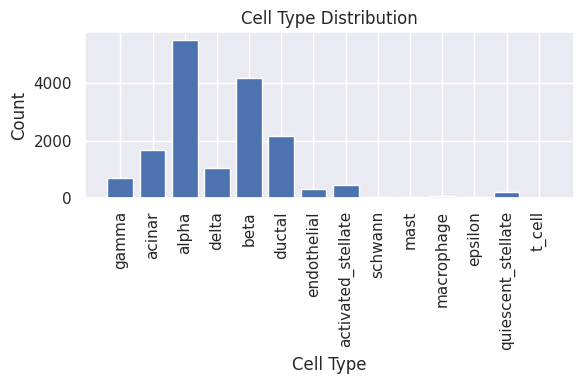


📈 Cell type percentages:
gamma: 4.3%
acinar: 10.2%
alpha: 33.5%
delta: 6.4%
beta: 25.4%
ductal: 13.1%
endothelial: 1.9%
activated_stellate: 2.8%
schwann: 0.2%
mast: 0.3%
macrophage: 0.5%
epsilon: 0.2%
quiescent_stellate: 1.2%
t_cell: 0.0%


In [44]:
# The Counter is used here to count the frequency of each cell type in your dataset. Let me explain why this is important:

import matplotlib.pyplot as plt

celltype_counter = Counter(original_dataset["celltype"])
print(f"\n📊 Cell type distribution (raw counts): {celltype_counter}")

plt.figure(figsize=(6, 4))
plt.bar(celltype_counter.keys(), celltype_counter.values())
plt.xlabel("Cell Type")
plt.ylabel("Count")
plt.title("Cell Type Distribution")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

# 🔢 Calculate and print percentages
total = sum(celltype_counter.values())
percentages = {cell: f"{100 * count / total:.1f}%" for cell, count in celltype_counter.items()}
print("\n📈 Cell type percentages:")
for cell_type, pct in percentages.items():
    print(f"{cell_type}: {pct}")

**To Identify Rare Cell Types**

*clusters_to_keep = [k for k, v in celltype_counter.items() if v > len(train_data) * 0.005]*

and to filter out cell types that appear in less than 0.5% of your data, and  to prevent training problems.

**Class imbalance:** If you have 10,000 acinar cells but only 5 rare cells, the model will be biased.

**Insufficient samples:** Can't learn meaningful patterns from very few examples

**Poor generalization:** Model might overfit to rare classes.

In [45]:
# Keep cell types that appear in more than 0.1 of training data

threshold = 0.1  # 10% expressed as a decimal
min_cells = len(original_dataset) * threshold

clusters_to_keep = [k for k, v in celltype_counter.items() if v > min_cells]
print(f"\n✅ Cell types to keep (>0.1% threshold = {int(min_cells)} cells): {len(clusters_to_keep)} types")
print(f"🧪 Retained cell types: {clusters_to_keep}")

# ℹ️ Quick breakdown of pancreatic islet cell types
print("""
🔬 Pancreatic islet cell functions:
- Beta (β): secrete insulin (lowers blood glucose)
- Alpha (α): secrete glucagon (raises blood glucose)
- Delta (δ): secrete somatostatin (inhibits insulin and glucagon)
- PP (γ/F): secrete pancreatic polypeptide
- Epsilon (ε): secrete ghrelin
""")

# 📊 Compute and display filtered cell type distribution
total_cells = sum(celltype_counter[k] for k in clusters_to_keep)

print("📈 Cell type distribution (filtered):")
for k in clusters_to_keep:
    count = celltype_counter[k]
    pct = 100 * count / total_cells
    print(f"{k}: {count} cells ({pct:.2f}%)")



✅ Cell types to keep (>0.1% threshold = 1638 cells): 4 types
🧪 Retained cell types: ['acinar', 'alpha', 'beta', 'ductal']

🔬 Pancreatic islet cell functions:
- Beta (β): secrete insulin (lowers blood glucose)
- Alpha (α): secrete glucagon (raises blood glucose)
- Delta (δ): secrete somatostatin (inhibits insulin and glucagon)
- PP (γ/F): secrete pancreatic polypeptide
- Epsilon (ε): secrete ghrelin

📈 Cell type distribution (filtered):
acinar: 1669 cells (12.39%)
alpha: 5493 cells (40.77%)
beta: 4169 cells (30.94%)
ductal: 2142 cells (15.90%)


In [46]:
# Step 1: Filter data to keep only frequent cell types
filtered_data = original_dataset.filter(lambda x: x["celltype"] in clusters_to_keep, num_proc=16)

# Step 2: Keep only cells with full-length tokenization
filtered_data = filtered_data.filter(lambda x: x["length"] == 2048, num_proc=16)

# Step 3: Add a new column 'label' that copies 'celltype'
filtered_data = filtered_data.map(lambda x: {"label": x["celltype"]})

# Step 4: Shuffle the dataset for unbiased splits
shuffled_data = filtered_data.shuffle(seed=42)

# Step 5: Inspect the DataFrame
df = shuffled_data.to_pandas()
print(df.head())
print(f"\n📊 Shape of shuffled dataset: {df.shape}")

# ✅ Now shuffled_data will contain both celltype and label columns.

# instead of Renaming (shuffle + rename_column) :
# shuffled_data = filtered_data.shuffle(seed=42).rename_column("celltype", "label")

# Why rename to "label"?
# Standard ML convention - most training frameworks expect a column called "label"
# HuggingFace compatibility - Trainer expects numerical labels in a "label" column
# Prepares for next step - where we'll convert text labels to numbers

# Why shuffle?
# Randomizes order of cells in the dataset
# Prevents bias during train/eval splits
# seed=42 ensures reproducible results

# Why do we shuffle a dataset?

# Avoid Ordering Bias
# Biological or technical datasets may have samples grouped by condition, timepoint, or batch.
# If we don't shuffle, training data might be biased (e.g., early batches all beta cells, later batches all alpha cells).

# Improve Generalization
# Helps models learn robust patterns by seeing more diverse examples early and throughout training.

# Ensure Balanced Batches
# Training in mini-batches benefits from a mix of classes or cell types.
# Shuffling helps maintain class balance across batches.

# Prevents Overfitting
# Learning from patterns in ordering (like repeated samples from the same donor) may cause overfitting.
# Shuffling breaks those patterns.

                                           input_ids      batch celltype  \
0  [23864, 11172, 20335, 7575, 12283, 6661, 20358...    celseq2    alpha   
1  [20826, 15251, 12283, 17299, 7575, 14954, 1218...    celseq2    alpha   
2  [14946, 18746, 544, 20275, 2187, 15251, 7783, ...    smarter     beta   
3  [25307, 20335, 6548, 3740, 5349, 5807, 7925, 1...    celseq2    alpha   
4  [11958, 25307, 12300, 2164, 4519, 12087, 17600...  smartseq2   ductal   

   n_counts         obs_names  size_factors       tech  length   label  
0      2690           D29-3_3      0.048099    celseq2    2048   alpha  
1      2947          D31-6_59      0.054338    celseq2    2048   alpha  
2      4517        Sample_678      1.000000    smarter    2048    beta  
3      2601          D28-5_40      0.045600    celseq2    2048   alpha  
4      7161  HP1508501T2D_N17      3.795446  smartseq2    2048  ductal  

📊 Shape of shuffled dataset: (8402, 9)


To downsize the data to 3000 cells, keeping the same % of cells, nin order not to get CUDA out of memory ("CUDA out of memory. Tried to allocate 1.56 GiB. GPU 0 has a total capacity of 39.56 GiB of which 404.88 MiB is free. Process 5476 has 39.15 GiB memory in use. Of the allocated memory 37.55 GiB is allocated by PyTorch, and 1.11 GiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management")  

In [48]:
# The percentage of each cell type in the shuffled_data

from collections import Counter

# Count cell types
celltype_counter = Counter(shuffled_data["celltype"])

# Compute percentages
total_cells = sum(celltype_counter.values())
percentages = {cell: 100 * count / total_cells for cell, count in celltype_counter.items()}

# Print results
print(f"\n📊 Cell type distribution in shuffled dataset (total = {total_cells} cells):")
for cell_type, count in celltype_counter.items():
    pct = percentages[cell_type]
    print(f"{cell_type}: {count} cells ({pct:.2f}%)")

import matplotlib.pyplot as plt

# === Pie Chart Visualization ===
labels = [f"{cell} ({count}, {percentages[cell]:.1f}%)" for cell, count in celltype_counter.items()]
sizes = list(celltype_counter.values())

plt.figure(figsize=(5, 5))
plt.pie(sizes, labels=labels, startangle=140, wedgeprops={"edgecolor": "white"})
plt.title(f"📊 Cell Type Distribution (n = {total_cells} cells)", fontsize=10)
plt.axis("equal")  # Equal aspect ratio ensures the pie is round
plt.tight_layout()
plt.show()


📊 Cell type distribution in shuffled dataset (total = 8402 cells):
alpha: 3516 cells (41.85%)
beta: 2304 cells (27.42%)
ductal: 1558 cells (18.54%)
acinar: 1024 cells (12.19%)


In [49]:
target_total = 1000

**Down-sampling **

Total target cells

target_total = 1000

In [50]:
# ✅ Next step: Create the downsampled dataset
from datasets import concatenate_datasets

# === Compute sample sizes based on existing proportions ===
sample_sizes = {
    k: int(round(v / total_cells * target_total)) for k, v in celltype_counter.items()
}

# Adjust to ensure total is exactly target_total (e.g., 2000)
diff = target_total - sum(sample_sizes.values())
if diff != 0:
    largest = max(sample_sizes, key=sample_sizes.get)
    sample_sizes[largest] += diff

# === Downsample each group ===
downsampled_groups = [
    shuffled_data.filter(lambda x: x["celltype"] == k).shuffle(seed=42).select(range(sample_sizes[k]))
    for k in sample_sizes
]

# === Combine downsampled groups ===
downsampled_dataset = concatenate_datasets(downsampled_groups)

# === Check final cell distribution ===
final_counts = Counter(downsampled_dataset["celltype"])
print(f"\n✅ Final downsampled dataset (n = {target_total}):")
for k, v in final_counts.items():
    print(f"{k}: {v} cells ({100 * v / target_total:.2f}%)")

print(f"🎯 Downsampled dataset contains {len(downsampled_dataset)} cells.")
print("📊 Distribution:")
from collections import Counter
from pprint import pprint

ct_counts = Counter(downsampled_dataset["celltype"])
pprint({k: f"{v} cells ({v / len(downsampled_dataset) * 100:.2f}%)" for k, v in ct_counts.items()})


✅ Final downsampled dataset (n = 1000):
alpha: 419 cells (41.90%)
beta: 274 cells (27.40%)
ductal: 185 cells (18.50%)
acinar: 122 cells (12.20%)
🎯 Downsampled dataset contains 1000 cells.
📊 Distribution:
{'acinar': '122 cells (12.20%)',
 'alpha': '419 cells (41.90%)',
 'beta': '274 cells (27.40%)',
 'ductal': '185 cells (18.50%)'}


In [51]:
# Now, downsampled_dataset is the actual object to use going forward — for example, for splitting into train/test:

# x = downsampled_dataset.train_test_split(test_size=0.2, seed=42)
# pancreas_trainset = x["train"]
# pancreas_evalset = x["test"]

train_data = downsampled_dataset

**Input training data : to create numerical labels**

In [52]:
# Create numerical labels from downsampled train_data
target_names = sorted(list(set(train_data["label"])))
celltype_label_dict = {name: idx for idx, name in enumerate(target_names)}
print(f"Label mapping: {celltype_label_dict}")

# Map string labels to numerical values
def map_labels(example):
    example["label"] = celltype_label_dict[example["label"]]
    return example

# Apply the mapping
labeled_data = train_data.map(map_labels, num_proc=16)

# Convert to pandas for inspection
import pandas as pd
df = labeled_data.to_pandas()
print(df.head())

Label mapping: {'acinar': 0, 'alpha': 1, 'beta': 2, 'ductal': 3}
                                           input_ids       batch celltype  \
0  [20335, 25307, 9442, 3740, 12087, 15251, 6661,...   smartseq2    alpha   
1  [25221, 19811, 7472, 2187, 6661, 17444, 12173,...     smarter    alpha   
2  [9147, 18596, 25307, 10764, 17299, 18746, 2570...     smarter    alpha   
3  [3598, 161, 8100, 18827, 12377, 14946, 8546, 6...  fluidigmc1    alpha   
4  [23864, 20335, 7804, 18531, 8455, 10566, 12923...      celseq    alpha   

   n_counts     obs_names  size_factors        tech  length  label  
0      3657  HP1509101_N5      0.103218   smartseq2    2048      1  
1      4638    Sample_433      1.000000     smarter    2048      1  
2      4431    Sample_379      1.000000     smarter    2048      1  
3      7460     3rd-C9_S5     13.532952  fluidigmc1    2048      1  
4      3026        D74_42      0.054678      celseq    2048      1  


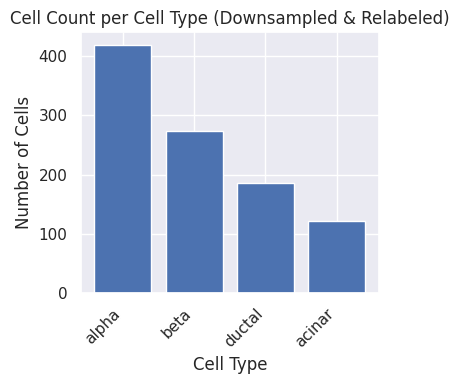


📊 Percentage of each label class:
acinar: 12.20%
alpha: 41.90%
beta: 27.40%
ductal: 18.50%


In [53]:
from collections import Counter
import matplotlib.pyplot as plt

# Count number of cells per numeric label
cell_counts = Counter(labeled_data["label"])

# Sort by count
sorted_items = sorted(cell_counts.items(), key=lambda x: x[1], reverse=True)
labels, counts = zip(*sorted_items)

# Optionally map numeric labels back to cell type names for the x-axis
inverse_label_map = {v: k for k, v in celltype_label_dict.items()}
x_labels = [inverse_label_map[i] for i in labels]

# Plot
plt.figure(figsize=(4, 4))
plt.bar(x_labels, counts)
plt.xlabel("Cell Type")
plt.ylabel("Number of Cells")
plt.title("Cell Count per Cell Type (Downsampled & Relabeled)")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Count occurrences of each numeric label
label_counts = Counter(labeled_data["label"])
total = sum(label_counts.values())

# Reverse mapping: numeric label → cell type name
label_to_celltype = {v: k for k, v in celltype_label_dict.items()}

# Print percentages
print("\n📊 Percentage of each label class:")
for label, count in sorted(label_counts.items()):
    cell_type = label_to_celltype[label]
    pct = 100 * count / total
    print(f"{cell_type}: {pct:.2f}%")

In [54]:
# Train/eval split (80% train, 20% eval from the filtered data)
train_size = round(len(labeled_data) * 0.8)
pancreas_trainset = labeled_data.select(range(train_size))
pancreas_evalset = labeled_data.select(range(train_size, len(labeled_data)))

print(f"Training set size: {len(pancreas_trainset)}")
print(f"Evaluation set size: {len(pancreas_evalset)}")
print(f"Number of unique cell types: {len(celltype_label_dict)}")

Training set size: 800
Evaluation set size: 200
Number of unique cell types: 4


In [55]:
print(f"{output_dir}")

# Load dataset from disk to verify
# Save datasets for later use
pancreas_trainset.save_to_disk(f"{output_dir}/pancreas_labeled_train.dataset")
pancreas_evalset.save_to_disk(f"{output_dir}/pancreas_labeled_eval.dataset")

for fname in os.listdir(output_dir):
    print(os.path.join(output_dir, fname))

/content/pancreas_scib.classification_output
/content/pancreas_scib.classification_output/pancreas_scib_id_class_dict.pkl
/content/pancreas_scib.classification_output/pancreas_labeled_eval.dataset
/content/pancreas_scib.classification_output/pancreas_labeled_train.dataset


In [56]:
# Show column names (metadata) for each dataset
print("📋 labeled_data columns:")
print(labeled_data.column_names)

print("\n📋 pancreas_trainset columns:")
print(pancreas_trainset.column_names)

print("\n📋 pancreas_evalset columns:")
print(pancreas_evalset.column_names)


📋 labeled_data columns:
['input_ids', 'batch', 'celltype', 'n_counts', 'obs_names', 'size_factors', 'tech', 'length', 'label']

📋 pancreas_trainset columns:
['input_ids', 'batch', 'celltype', 'n_counts', 'obs_names', 'size_factors', 'tech', 'length', 'label']

📋 pancreas_evalset columns:
['input_ids', 'batch', 'celltype', 'n_counts', 'obs_names', 'size_factors', 'tech', 'length', 'label']


In [57]:
# ============================================================================
# METRICS
# ============================================================================

def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    # calculate accuracy and macro f1 using sklearn's function
    acc = accuracy_score(labels, preds)
    macro_f1 = f1_score(labels, preds, average='macro')
    return {
      'accuracy': acc,
      'macro_f1': macro_f1
    }

In [58]:
import torch
import gc

# Clear GPU cache
torch.cuda.empty_cache()
gc.collect()

# Check GPU memory
print(f"GPU memory allocated: {torch.cuda.memory_allocated() / 1024**3:.2f} GB")
print(f"GPU memory reserved: {torch.cuda.memory_reserved() / 1024**3:.2f} GB")

GPU memory allocated: 0.00 GB
GPU memory reserved: 0.00 GB


In [59]:
import torch
torch.cuda.empty_cache()
print(f"CUDA memory after empty_cache: {torch.cuda.memory_allocated() / (1024**3):.2f} GB")
# ... your model loading and training code

CUDA memory after empty_cache: 0.00 GB


**🔧 Hyperparameters :**

**max_input_size = 2048**

Maximum number of tokens (genes) per cell input.

If a cell expresses more than 2048 genes, it will be truncated; if fewer, it may be padded.

**geneformer_batch_size = 5**

Number of examples (cells) processed in one forward/backward pass.

A small batch size reduces memory usage but may make training slower or noisier.

**max_lr = 5e-5**

Maximum learning rate (i.e., 0.00005).

Controls the step size during optimization. Too high can overshoot; too low may converge slowly.

**lr_schedule_fn = "linear"**

Learning rate schedule. "linear" means the learning rate will decay linearly from max_lr to 0 across training steps.

Helps the model stabilize after initial updates.

**warmup_steps = 500**

Number of steps over which the learning rate will increase linearly from 0 to max_lr.

Helps prevent sudden jumps at the beginning of training.

**epochs = 30**

Number of full passes through the training dataset.

More epochs mean more training time and potential overfitting if too high.

**optimizer = "adamw"**

Optimization algorithm. AdamW is a version of Adam that decouples weight decay from the gradient update.

Well-suited for transformer-based models.

**freeze_layers = 0**

Number of transformer layers to "freeze" (not update during training).

If set > 0, the first freeze_layers will be frozen; 0 means the full model is trainable

**🔍 What is TrainingArguments?**

TrainingArguments is a class provided by the Hugging Face transformers library. It defines all the parameters needed to train or evaluate a model using the Trainer API.

```
training_args = {
    "learning_rate": 5e-5,
    "do_train": True,
    "do_eval": True,
    "eval_strategy": "epoch",
    "save_strategy": "epoch",
    "logging_steps": 100,
    "group_by_length": True,
    "length_column_name": "length",
    "disable_tqdm": False,
    "lr_scheduler_type": "linear",
    "warmup_steps": 500,
    "weight_decay": 0.01,
    "per_device_train_batch_size": 8,
    "per_device_eval_batch_size": 8,
    "num_train_epochs": 3,
    "load_best_model_at_end": True,

```


In [60]:
# Hyperparameters (adapted from the simple approach)

num_proc = 16  # Number of processes for parallelism

# Not to get CUDA out of memory :
# In your hyperparameters section, change:
geneformer_batch_size = 5  # Reduce from 5 to 1

# set logging steps
logging_steps = round(len(pancreas_trainset)/geneformer_batch_size/10)

max_input_size = 2048
# max_input_size = 1024

max_lr = 5e-5

lr_schedule_fn = "linear"
# lr_schedule_fn = "cosine"
# lr_schedule_fn = "polynomial"

# warmup_steps = 100
warmup_steps = 500

epochs = 30

optimizer = "adamw"
freeze_layers = 0

# define output directory path

current_date = datetime.datetime.now()
datestamp = f"{str(current_date.year)[-2:]}{current_date.month:02d}{current_date.day:02d}"
model_output_dir = f"/content/models/{datestamp}_geneformer_CellClassifier_pancreas_L{max_input_size}_B{geneformer_batch_size}_LR{max_lr}_LS{lr_schedule_fn}_WU{warmup_steps}_E{epochs}_O{optimizer}_F{freeze_layers}/"

# ensure not overwriting previously saved model
saved_model_test = os.path.join(model_output_dir, f"pytorch_model.bin")
if os.path.isfile(saved_model_test) == True:
    raise Exception("Model already saved to this directory.")

# make output directory
os.makedirs(model_output_dir, exist_ok=True)

In [61]:
# ============================================================================
# SIMPLE TRAINING
# ============================================================================

# In another notebook, I have found these parameters :
# training_args = {
#    "per_device_train_batch_size": cellformer_batch_size,
#    "per_device_eval_batch_size": cellformer_batch_size,
#    "num_train_epochs": 0.9,
#    "learning_rate": 0.00087,
#    "lr_scheduler_type": "polynomial",
#    "warmup_steps": 1812,
#    "weight_decay":0.02828,
#    "seed": 73,
    # add other training hyperparameters as needed
# }


# set training arguments
training_args = {
    "learning_rate": max_lr,
    "do_train": True,
    "do_eval": True,
    "eval_strategy": "epoch",
    "save_strategy": "epoch",
    "logging_steps": logging_steps,
    "group_by_length": True,
    "length_column_name": "length",
    "disable_tqdm": False,
    "lr_scheduler_type": lr_schedule_fn,
    "warmup_steps": warmup_steps,
    #"weight_decay": 0.001,
     "weight_decay": 0.1,

     "per_device_train_batch_size": geneformer_batch_size,
     "per_device_eval_batch_size": geneformer_batch_size,
    #"per_device_train_batch_size": 1,
    #"per_device_eval_batch_size": 1,
    "num_train_epochs": epochs,
    "load_best_model_at_end": True,
    "output_dir": model_output_dir,

    # 🔥 ADD THESE MEMORY-SAVING OPTIONS:
    "gradient_checkpointing": True,
    "dataloader_pin_memory": False,
    "gradient_accumulation_steps": 4,  # Accumulate gradients
}

training_args_init = TrainingArguments(**training_args)
print(training_args_init)

TrainingArguments(
_n_gpu=1,
accelerator_config={'split_batches': False, 'dispatch_batches': None, 'even_batches': True, 'use_seedable_sampler': True, 'non_blocking': False, 'gradient_accumulation_kwargs': None, 'use_configured_state': False},
adafactor=False,
adam_beta1=0.9,
adam_beta2=0.999,
adam_epsilon=1e-08,
auto_find_batch_size=False,
average_tokens_across_devices=False,
batch_eval_metrics=False,
bf16=False,
bf16_full_eval=False,
data_seed=None,
dataloader_drop_last=False,
dataloader_num_workers=0,
dataloader_persistent_workers=False,
dataloader_pin_memory=False,
dataloader_prefetch_factor=None,
ddp_backend=None,
ddp_broadcast_buffers=None,
ddp_bucket_cap_mb=None,
ddp_find_unused_parameters=None,
ddp_timeout=1800,
debug=[],
deepspeed=None,
disable_tqdm=False,
do_eval=True,
do_predict=False,
do_train=True,
eval_accumulation_steps=None,
eval_delay=0,
eval_do_concat_batches=True,
eval_on_start=False,
eval_steps=None,
eval_strategy=IntervalStrategy.EPOCH,
eval_use_gather_object=False

```
model = BertForSequenceClassification.from_pretrained(
    MODEL,
    num_labels = len(celltype_label_dict.keys()),
    output_attentions = True,
    output_hidden_states = True
).to("cuda")
```

**🔍 Explanation**

**BertForSequenceClassification.from_pretrained(...)**

This loads a pretrained BERT model (like Geneformer) and adapts it for sequence classification — i.e., predicting a label for an input sequence (e.g., a cell's gene expression).

📌 Arguments

**MODEL**

This is a string path or model name pointing to a pretrained model directory (e.g., "geneformer" or "/content/models/geneformer_pretrained").

The model's weights and configuration will be loaded from this source.

**num_labels = len(celltype_label_dict.keys())**

Specifies how many distinct cell types (classes) the model should classify.

The final classification layer (nn.Linear) will output this many logits.

**output_attentions = True**

If True, the model will return attention weights for each layer and head.

Useful for interpreting which genes influenced the prediction.

**output_hidden_states = True**

If True, the model will return all hidden states from each layer.

These can be used for downstream tasks, feature extraction, or visualization.

**.to("cuda")**

Moves the model to the GPU, so training and inference can happen faster.

If you're not using a GPU, change it to .to("cpu")

In [62]:
# Check what columns you have
print("labeled_data columns:", labeled_data.column_names)
print("pancreas_trainset columns:", pancreas_trainset.column_names)
print("pancreas_evalset columns:", pancreas_evalset.column_names)

# Check sample data
print("\nSample from pancreas_trainset:")
print(pancreas_trainset[0])

# Check if you have celltype_label_dict
if 'celltype_label_dict' in locals():
    print("\ncelltype_label_dict:", celltype_label_dict)

# Check if you have celltype_label_dict
print("🔍 labeled_data features:")
print(labeled_data.features)

print("\n🔍 pancreas_trainset features:")
print(pancreas_trainset.features)

print("\n🔍 pancreas_evalset features:")
print(pancreas_evalset.features)

labeled_data columns: ['input_ids', 'batch', 'celltype', 'n_counts', 'obs_names', 'size_factors', 'tech', 'length', 'label']
pancreas_trainset columns: ['input_ids', 'batch', 'celltype', 'n_counts', 'obs_names', 'size_factors', 'tech', 'length', 'label']
pancreas_evalset columns: ['input_ids', 'batch', 'celltype', 'n_counts', 'obs_names', 'size_factors', 'tech', 'length', 'label']

Sample from pancreas_trainset:
{'input_ids': [20335, 25307, 9442, 3740, 12087, 15251, 6661, 4949, 467, 17623, 20130, 20519, 301, 10356, 2957, 4519, 6439, 11815, 7495, 10072, 6516, 11159, 14868, 4096, 13586, 7211, 8262, 13398, 3665, 7575, 1595, 5442, 23127, 18719, 10558, 14833, 14796, 13639, 5847, 2249, 4625, 3291, 13909, 24147, 12283, 11645, 12156, 14163, 20418, 2405, 2823, 12923, 15918, 5759, 20358, 13150, 10525, 7512, 20847, 14054, 16511, 7557, 17759, 219, 4568, 11640, 20275, 3546, 1268, 11728, 7472, 5418, 2589, 4466, 12558, 20278, 9566, 2413, 5419, 12070, 7372, 10238, 3012, 15239, 8915, 7071, 7232, 2396, 

In [63]:
MODEL = model_v1

In [64]:
# ============================================================================
# TRAINING LOOP
# ============================================================================

print("Starting pancreas cell type classification...")

# We use: pancreas_trainset (already prepared above)
# We use: pancreas_evalset (already prepared above)
# We use: cell_type_label_dict (already prepared above)


# reload pretrained model
model = BertForSequenceClassification.from_pretrained(MODEL,
                                                      num_labels = len(celltype_label_dict.keys()),
                                                      output_attentions = False,
                                                      output_hidden_states = False).to("cuda")


# Freeze initial layers if specified
if freeze_layers > 0:
    for param in model.bert.embeddings.parameters():
        param.requires_grad = False
    for i in range(freeze_layers):
        for param in model.bert.encoder.layer[i].parameters():
            param.requires_grad = False


model.gradient_checkpointing_enable()

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at /content/Geneformer/Geneformer-V1-10M/ and are newly initialized: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight', 'classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Starting pancreas cell type classification...


In [65]:
import torch
torch.cuda.empty_cache()

In [66]:
# Load token dictionary
with open(token_dictionary, "rb") as f:
    token_dict = pickle.load(f)

data_collator = DataCollatorForCellClassification(token_dictionary=token_dict)

# create the trainer
trainer = Trainer(
    model = model,
    args = training_args_init,
    data_collator = data_collator,
    train_dataset = pancreas_trainset,
    eval_dataset = pancreas_evalset,
    compute_metrics = compute_metrics # ← This is where you pass the function
)

# train the cell type classifier
trainer.train()

predictions = trainer.predict(pancreas_evalset)

with open(f"{model_output_dir}predictions.pickle", "wb") as fp:
    pickle.dump(predictions, fp)

trainer.save_metrics("eval", predictions.metrics)
trainer.save_model(model_output_dir)

print("✅ Training complete!")
print(f"Model saved to: {model_output_dir}")

wandb: WARNING The `run_name` is currently set to the same value as `TrainingArguments.output_dir`. If this was not intended, please specify a different run name by setting the `TrainingArguments.run_name` parameter.
wandb: Currently logged in as: tanasa (tanasa-sb) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


/content/Geneformer/geneformer/collator_for_classification.py:649: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  batch = {k: torch.tensor(v.clone().detach(), dtype=torch.int64) if isinstance(v, torch.Tensor) else torch.tensor(v, dtype=torch.int64) for k, v in batch.items()}


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,1.342600,1.475945,0.010000,0.012346
2,1.206200,1.705239,0.000000,0.000000
3,1.095300,2.041766,0.000000,0.000000
4,0.998800,2.158074,0.000000,0.000000
5,0.923600,1.870399,0.250000,0.134409
6,0.799200,1.718940,0.385000,0.188725
7,0.732200,1.643883,0.385000,0.185319
8,0.612000,1.674921,0.385000,0.185319
9,0.540900,1.728403,0.390000,0.280576
10,0.334500,1.786779,0.385000,0.185319


/content/Geneformer/geneformer/collator_for_classification.py:649: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  batch = {k: torch.tensor(v.clone().detach(), dtype=torch.int64) if isinstance(v, torch.Tensor) else torch.tensor(v, dtype=torch.int64) for k, v in batch.items()}
/content/Geneformer/geneformer/collator_for_classification.py:649: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  batch = {k: torch.tensor(v.clone().detach(), dtype=torch.int64) if isinstance(v, torch.Tensor) else torch.tensor(v, dtype=torch.int64) for k, v in batch.items()}
/content/Geneformer/geneformer/collator_for_classification.py:649: UserWarning: To copy construct from a tensor, it is recommended to use sourceTe

✅ Training complete!
Model saved to: /content/models/250717_geneformer_CellClassifier_pancreas_L2048_B5_LR5e-05_LSlinear_WU500_E30_Oadamw_F0/


In [67]:
# Get final results from training log (epoch 30)

print(trainer.state.log_history)
final_log = trainer.state.log_history[-2]  # -2 because last entry is usually training end
final_accuracy = final_log.get('eval_accuracy', 0.0)
final_f1 = final_log.get('eval_macro_f1', 0.0)

print(f"Final Results (Epoch 30):")
print(f"  Accuracy: {final_accuracy:.3f}")
print(f"  F1 Score: {final_f1:.3f}")

# Show training progression
print(f"\nTraining Progress:")
eval_logs = [log for log in trainer.state.log_history if 'eval_accuracy' in log]
if eval_logs:
    first_acc = eval_logs[0].get('eval_accuracy', 0.0)
    last_acc = eval_logs[-1].get('eval_accuracy', 0.0)
    print(f"  Epoch 1: {first_acc:.3f}")
    print(f"  Epoch {len(eval_logs)}: {last_acc:.3f}")

print(f"\nDataset: {len(pancreas_trainset)} train, {len(pancreas_evalset)} eval")
print(f"Cell types: {len(celltype_label_dict)}")

[{'loss': 1.3631, 'grad_norm': 4.013912677764893, 'learning_rate': 1.5e-06, 'epoch': 0.4, 'step': 16}, {'loss': 1.3426, 'grad_norm': 3.507816791534424, 'learning_rate': 3.1e-06, 'epoch': 0.8, 'step': 32}, {'eval_loss': 1.4759448766708374, 'eval_accuracy': 0.01, 'eval_macro_f1': 0.012345679012345678, 'eval_runtime': 0.8531, 'eval_samples_per_second': 234.447, 'eval_steps_per_second': 46.889, 'epoch': 1.0, 'step': 40}, {'loss': 1.3193, 'grad_norm': 2.4720423221588135, 'learning_rate': 4.7e-06, 'epoch': 1.2, 'step': 48}, {'loss': 1.2714, 'grad_norm': 3.007472276687622, 'learning_rate': 6.300000000000001e-06, 'epoch': 1.6, 'step': 64}, {'loss': 1.2062, 'grad_norm': 1.887400507926941, 'learning_rate': 7.9e-06, 'epoch': 2.0, 'step': 80}, {'eval_loss': 1.7052390575408936, 'eval_accuracy': 0.0, 'eval_macro_f1': 0.0, 'eval_runtime': 0.866, 'eval_samples_per_second': 230.957, 'eval_steps_per_second': 46.191, 'epoch': 2.0, 'step': 80}, {'loss': 1.1533, 'grad_norm': 2.235194444656372, 'learning_ra

In [68]:
# 📦 Common metadata fields in Geneformer .dataset files include:

# Column Name	Description

# input_ids	    Tokenized gene expression values (used for model input)
# label	        The target class (numeric or string) for classification
# celltype	    Original cell type label (if not renamed)
# n_counts	    Number of RNA molecules per cell
# obs_names	    Unique cell/sample identifiers
# size_factors	Normalization factor for expression values
# tech	        Sequencing technology used (e.g., Smart-seq2, 10x Genomics)
# length	      Length of the input_ids vector (often 2048 for Geneformer)
# batch	        Batch ID, if included

print(original_dataset.features)
print(original_dataset.column_names)

# Load dataset from disk to verify
# pancreas_test_dataset = load_from_disk(f"{output_dir}/{input_prefix}_labeled_test.dataset")
# print(pancreas_test_dataset)
# pancreas_train_dataset = load_from_disk(f"{output_dir}/{input_prefix}_labeled_train.dataset")
# print(pancreas_train_dataset)


{'input_ids': Sequence(feature=Value(dtype='int16', id=None), length=-1, id=None), 'batch': Value(dtype='string', id=None), 'celltype': Value(dtype='string', id=None), 'n_counts': Value(dtype='int64', id=None), 'obs_names': Value(dtype='string', id=None), 'size_factors': Value(dtype='float64', id=None), 'tech': Value(dtype='string', id=None), 'length': Value(dtype='int64', id=None)}
['input_ids', 'batch', 'celltype', 'n_counts', 'obs_names', 'size_factors', 'tech', 'length']


In [70]:
!ls -s /content/models/250717_geneformer_CellClassifier_pancreas_L2048_B5_LR5e-05_LSlinear_WU500_E30_Oadamw_F0

total 40320
    4 all_results.json	    4 checkpoint-200       4 checkpoint-640
    4 checkpoint-1000	    4 checkpoint-2000      4 checkpoint-680
    4 checkpoint-1040	    4 checkpoint-2080      4 checkpoint-720
    4 checkpoint-1080	    4 checkpoint-2160      4 checkpoint-760
    4 checkpoint-1120	    4 checkpoint-2240      4 checkpoint-80
    4 checkpoint-1160	    4 checkpoint-2320      4 checkpoint-800
    4 checkpoint-120	    4 checkpoint-240       4 checkpoint-840
    4 checkpoint-1200	    4 checkpoint-2400      4 checkpoint-880
    4 checkpoint-1280	    4 checkpoint-280       4 checkpoint-920
    4 checkpoint-1360	    4 checkpoint-320       4 checkpoint-960
    4 checkpoint-1440	    4 checkpoint-360       4 config.json
    4 checkpoint-1520	    4 checkpoint-40        4 eval_results.json
    4 checkpoint-160	    4 checkpoint-400   40108 model.safetensors
    4 checkpoint-1600	    4 checkpoint-440       8 predictions.pickle
    4 checkpoint-1680	    4 checkpoint-480       4 runs
   

In [69]:
!echo -e "\ninput dataset\n"
!ls -1 /content/pancreas_scib.dataset
!echo -e "\noutput folder\n"
!ls -s /content/pancreas_scib.classification_output
!echo -e "\ntrain dataset\n"
!ls -s /content/pancreas_scib.classification_output/pancreas_labeled_train.dataset
!echo -e "\neval dataset\n"
!ls -s /content/pancreas_scib.classification_output/pancreas_labeled_eval.dataset


input dataset

data-00000-of-00001.arrow
dataset_info.json
state.json

output folder

total 12
4 pancreas_labeled_eval.dataset   4 pancreas_scib_id_class_dict.pkl
4 pancreas_labeled_train.dataset

train dataset

total 3280
3272 data-00000-of-00001.arrow	   4 dataset_info.json	   4 state.json

eval dataset

total 828
820 data-00000-of-00001.arrow    4 dataset_info.json    4 state.json


In [71]:
from datasets import load_from_disk
import pickle

# Should we be able to find the <cls> token

# Load dataset
dataset = load_from_disk("/content/drive/My Drive/geneformer_test2/pancreas_scib.dataset")

# Load the Geneformer token dictionary
with open("/content/Geneformer/geneformer/gene_dictionaries_30m/token_dictionary_gc30M.pkl", "rb") as f:
    token_dict = pickle.load(f)


print("Number of tokens:", len(token_dict))
print("Sample keys:", list(token_dict.keys())[:10])
for key in token_dict.keys():
    if str(key).lower() == "<cls>":
        print("Found <cls> as key:", key)

Number of tokens: 25426
Sample keys: ['<pad>', '<mask>', 'ENSG00000000003', 'ENSG00000000005', 'ENSG00000000419', 'ENSG00000000457', 'ENSG00000000460', 'ENSG00000000938', 'ENSG00000000971', 'ENSG00000001036']
